In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import interpolate
from sklearn import preprocessing as p

## Cleaning data

In [3]:
#importing data from Modulair MOD-000679
winddata = pd.read_csv('MOD-00679-2-27data.csv').set_index('timestamp')
winddata.head()

,id,timestamp_local,sn,rh,temp,bin0,bin1,bin2,bin3,bin4,...,no2,o3,pm1_model_id,pm25_model_id,pm10_model_id,co_model_id,no_model_id,no2_model_id,o3_model_id,ws_scalar
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-12-31T23:59:42Z,577612018,2025-12-31T18:59:42Z,MOD-00679,49.4,0.2,5.711,0.844,0.341,0.071,0.046,...,31.630,27.138,14310.0,14311.0,14312.0,14466.0,14491.0,14541.0,14516.0,1.58
2025-12-31T23:58:42Z,577612014,2025-12-31T18:58:42Z,MOD-00679,49.2,0.1,5.916,0.818,0.337,0.107,0.059,...,31.394,27.506,14310.0,14311.0,14312.0,14466.0,14491.0,14541.0,14516.0,1.20
2025-12-31T23:57:42Z,577610060,2025-12-31T18:57:42Z,MOD-00679,49.0,0.1,5.734,1.020,0.294,0.103,0.056,...,31.165,27.878,14310.0,14311.0,14312.0,14466.0,14491.0,14541.0,14516.0,1.05
2025-12-31T23:56:42Z,577610059,2025-12-31T18:56:42Z,MOD-00679,48.9,0.1,5.723,0.806,0.241,0.078,0.036,...,30.933,28.238,14310.0,14311.0,14312.0,14466.0,14491.0,14541.0,14516.0,2.02
2025-12-31T23:55:42Z,577610061,2025-12-31T18:55:42Z,MOD-00679,49.0,0.1,5.317,0.855,0.325,0.087,0.033,...,30.928,27.878,14310.0,14311.0,14312.0,14466.0,14491.0,14541.0,14516.0,1.31


In [4]:
#only columns of interest
COLS_TO_INCLUDE = ['timestamp_local','wd','ws']
winddata = winddata[COLS_TO_INCLUDE]

winddata.head()

,timestamp_local,wd,ws
timestamp,,,
2025-12-31T23:59:42Z,2025-12-31T18:59:42Z,195.0,1.33
2025-12-31T23:58:42Z,2025-12-31T18:58:42Z,258.1,0.98
2025-12-31T23:57:42Z,2025-12-31T18:57:42Z,242.2,0.67
2025-12-31T23:56:42Z,2025-12-31T18:56:42Z,232.2,1.36
2025-12-31T23:55:42Z,2025-12-31T18:55:42Z,121.4,0.23


In [5]:
#removing the UTC time
winddata = winddata.reset_index(drop = True)
winddata.head()

,timestamp_local,wd,ws
0,2025-12-31T18:59:42Z,195.0,1.33
1,2025-12-31T18:58:42Z,258.1,0.98
2,2025-12-31T18:57:42Z,242.2,0.67
3,2025-12-31T18:56:42Z,232.2,1.36
4,2025-12-31T18:55:42Z,121.4,0.23


In [6]:
#converting to datetime
winddata['timestamp_local'] = pd.to_datetime(winddata['timestamp_local'],
                                       format='%Y-%m-%dT%H:%M:%SZ',
                                       exact=False)
winddata.head()

,timestamp_local,wd,ws
0,2025-12-31 18:59:42,195.0,1.33
1,2025-12-31 18:58:42,258.1,0.98
2,2025-12-31 18:57:42,242.2,0.67
3,2025-12-31 18:56:42,232.2,1.36
4,2025-12-31 18:55:42,121.4,0.23


In [7]:
#taking hourly average of df. round to floor of the hour
winddata = winddata.groupby(winddata['timestamp_local'].dt.floor('h')).agg(wd = ('wd','mean'),
                                                                           ws = ('ws','mean')).reset_index()

winddata = winddata.round(decimals = 2)
winddata = winddata.dropna()
winddata

,timestamp_local,wd,ws
0,2025-04-15 08:00:00,0.00,0.00
1,2025-04-25 10:00:00,0.00,0.00
2,2025-04-25 11:00:00,0.00,0.00
3,2025-04-25 12:00:00,181.82,4.85
4,2025-04-25 13:00:00,195.82,4.10
...,...,...,...
5962,2025-12-31 14:00:00,283.29,4.38
5963,2025-12-31 15:00:00,277.23,4.13
5964,2025-12-31 16:00:00,272.62,4.57
5965,2025-12-31 17:00:00,225.74,2.08


In [8]:
ts = pd.read_csv('MOD-000679_timeseries_hourly_scaled.csv')
ts.head()

,timestamp_local,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5
0,2025-04-25 13:00:00,0.536301,0.147252,0.833295,0.082859,0.087923,0.031390,0.025307,0.025229,0.040000,0.065217
1,2025-04-25 14:00:00,0.485643,0.144918,0.807340,0.231922,0.084015,0.034006,0.029646,0.029817,0.045714,0.072464
2,2025-04-25 15:00:00,0.432164,0.191598,0.779899,0.084108,0.075223,0.034006,0.029646,0.029817,0.045714,0.072464
3,2025-04-25 16:00:00,0.409734,0.253554,0.740567,0.060375,0.059836,0.028774,0.028200,0.032110,0.048571,0.072464
4,2025-04-25 17:00:00,0.385837,0.321239,0.730391,0.055656,0.071315,0.046338,0.033261,0.032110,0.048571,0.065217


In [9]:
results = pd.read_csv('679_factor_results.csv')
results.head()

,timestamp_local,Factor 1,Factor 2,Factor 3,Factor 4
0,2025-04-25 13:00:00,0.018333,0.008988,0.019904,0.192789
1,2025-04-25 14:00:00,0.017326,0.006995,0.023784,0.186278
2,2025-04-25 15:00:00,0.020806,0.003784,0.023231,0.173180
3,2025-04-25 16:00:00,0.026801,0.000252,0.024380,0.158699
4,2025-04-25 17:00:00,0.032730,0.003485,0.023199,0.148881


## Merging dataframes

In [10]:
data_1_2 = pd.merge(ts, results, on = 'timestamp_local', how = 'inner')
data_1_2

,timestamp_local,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5,Factor 1,Factor 2,Factor 3,Factor 4
0,2025-04-25 13:00:00,0.536301,0.147252,0.833295,0.082859,0.087923,0.031390,0.025307,0.025229,0.040000,0.065217,0.018333,0.008988,0.019904,0.192789
1,2025-04-25 14:00:00,0.485643,0.144918,0.807340,0.231922,0.084015,0.034006,0.029646,0.029817,0.045714,0.072464,0.017326,0.006995,0.023784,0.186278
2,2025-04-25 15:00:00,0.432164,0.191598,0.779899,0.084108,0.075223,0.034006,0.029646,0.029817,0.045714,0.072464,0.020806,0.003784,0.023231,0.173180
3,2025-04-25 16:00:00,0.409734,0.253554,0.740567,0.060375,0.059836,0.028774,0.028200,0.032110,0.048571,0.072464,0.026801,0.000252,0.024380,0.158699
4,2025-04-25 17:00:00,0.385837,0.321239,0.730391,0.055656,0.071315,0.046338,0.033261,0.032110,0.048571,0.065217,0.032730,0.003485,0.023199,0.148881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5866,2025-12-31 14:00:00,0.303950,0.621260,0.392065,0.027203,0.070460,0.020553,0.012292,0.011468,0.008571,0.007246,0.063563,0.010785,0.000000,0.045232
5867,2025-12-31 15:00:00,0.306438,0.634628,0.384862,0.025399,0.064110,0.022048,0.012292,0.009174,0.011429,0.007246,0.065051,0.009986,0.000000,0.042742
5868,2025-12-31 16:00:00,0.318312,0.635689,0.375486,0.032616,0.071071,0.023543,0.014461,0.011468,0.011429,0.014493,0.065293,0.012092,0.001568,0.041077
5869,2025-12-31 17:00:00,0.336975,0.657119,0.336039,0.034004,0.079131,0.029522,0.017354,0.016055,0.014286,0.014493,0.067789,0.016085,0.003647,0.031124


In [11]:
data_1_2['timestamp_local'] = pd.to_datetime(data_1_2['timestamp_local'])

In [12]:
data = pd.merge(data_1_2, winddata, on = 'timestamp_local', how = 'inner')
data

,timestamp_local,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5,Factor 1,Factor 2,Factor 3,Factor 4,wd,ws
0,2025-04-25 13:00:00,0.536301,0.147252,0.833295,0.082859,0.087923,0.031390,0.025307,0.025229,0.040000,0.065217,0.018333,0.008988,0.019904,0.192789,195.82,4.10
1,2025-04-25 14:00:00,0.485643,0.144918,0.807340,0.231922,0.084015,0.034006,0.029646,0.029817,0.045714,0.072464,0.017326,0.006995,0.023784,0.186278,185.78,4.69
2,2025-04-25 15:00:00,0.432164,0.191598,0.779899,0.084108,0.075223,0.034006,0.029646,0.029817,0.045714,0.072464,0.020806,0.003784,0.023231,0.173180,202.56,4.74
3,2025-04-25 16:00:00,0.409734,0.253554,0.740567,0.060375,0.059836,0.028774,0.028200,0.032110,0.048571,0.072464,0.026801,0.000252,0.024380,0.158699,189.76,4.71
4,2025-04-25 17:00:00,0.385837,0.321239,0.730391,0.055656,0.071315,0.046338,0.033261,0.032110,0.048571,0.065217,0.032730,0.003485,0.023199,0.148881,204.51,5.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5866,2025-12-31 14:00:00,0.303950,0.621260,0.392065,0.027203,0.070460,0.020553,0.012292,0.011468,0.008571,0.007246,0.063563,0.010785,0.000000,0.045232,283.29,4.38
5867,2025-12-31 15:00:00,0.306438,0.634628,0.384862,0.025399,0.064110,0.022048,0.012292,0.009174,0.011429,0.007246,0.065051,0.009986,0.000000,0.042742,277.23,4.13
5868,2025-12-31 16:00:00,0.318312,0.635689,0.375486,0.032616,0.071071,0.023543,0.014461,0.011468,0.011429,0.014493,0.065293,0.012092,0.001568,0.041077,272.62,4.57
5869,2025-12-31 17:00:00,0.336975,0.657119,0.336039,0.034004,0.079131,0.029522,0.017354,0.016055,0.014286,0.014493,0.067789,0.016085,0.003647,0.031124,225.74,2.08


## Plots

In [13]:
wd_rad = np.radians(np.array(data['wd'])) #deg to rad
ws = np.array(data['ws']) #m/s
Factor1 = np.array(data['Factor 1'])
Factor2 = np.array(data['Factor 2'])

In [14]:
WD, WS = np.meshgrid(np.linspace(0, 2*np.pi, 36), np.linspace(min(ws), max(ws), 16 ))
Z1 = interpolate.griddata((wd_rad, ws), Factor1, (WD, WS), method='linear')
Z2 = interpolate.griddata((wd_rad, ws), Factor2, (WD, WS), method='linear')

Z1 = np.nan_to_num(Z1, nan=1e-3)
Z2 = np.nan_to_num(Z2, nan=1e-3)

In [15]:
maxima = [np.max(i) for i in [Z1,Z2]]
maxima

[np.float64(0.07483659190853714), np.float64(0.14183236274266778)]

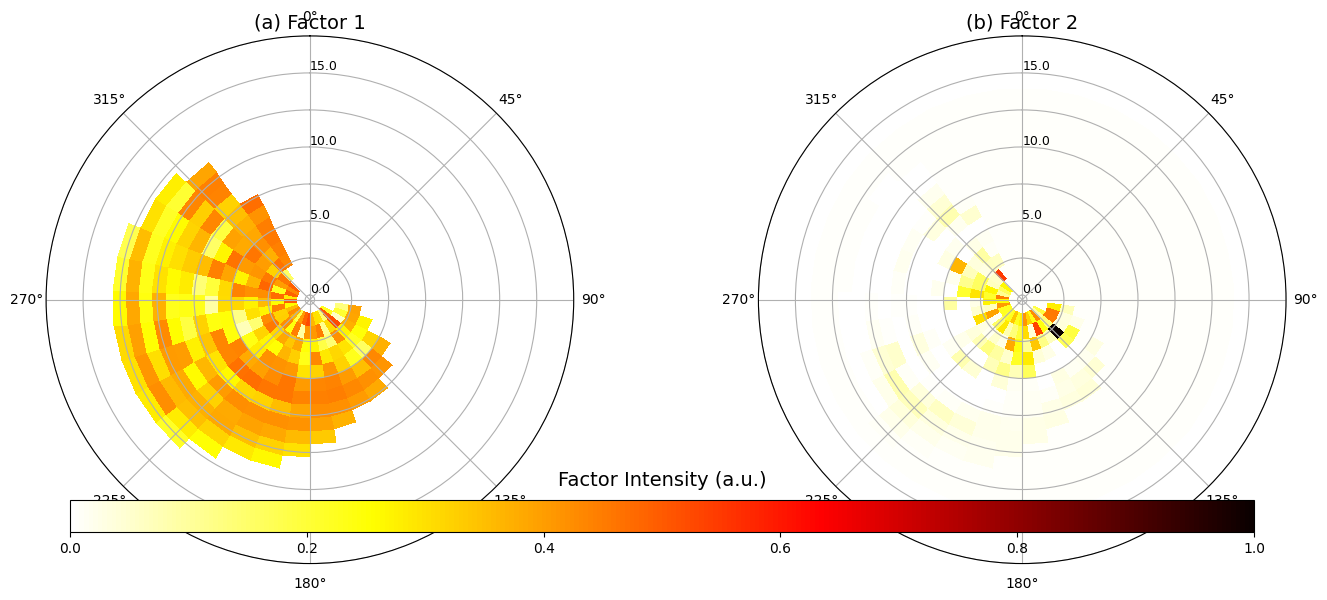

In [16]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 16), subplot_kw={'projection': 'polar'})
plt.subplots_adjust(wspace=0.35)
cmap = plt.get_cmap('hot_r')
cmap.set_under('none')

#change set-up to compass bearings
for i in range(2):
    ax[i].set_theta_zero_location('N')
    ax[i].set_theta_direction(-1)

#label
ax[0].set_title('(a) Factor 1',fontsize=14)
ax[1].set_title('(b) Factor 2',fontsize=14)

#plot
img1 = ax[0].pcolormesh(WD, WS, Z1, cmap=cmap, vmax = np.max(Z2))
img2 = ax[1].pcolormesh(WD, WS, Z2, cmap=cmap, vmax = np.max(Z2))

#label radial ticks
for i in range(2):
    ax[i].tick_params(axis='y', which='major', labelsize=9)
    ax[i].set_rticks([0,2.5,5,7.5,10,12.5,15,17.5])
    ax[i].set_rlabel_position(0)
    ax[i].set_yticklabels(['0.0','','5.0','','10.0','','15.0',''])

#set colorbar
cbar_ax = fig.add_axes([0.14, 0.35, 0.74, 0.02])
cbar = fig.colorbar(img2, cax=cbar_ax, orientation='horizontal')
cbar.set_ticks(list(np.linspace(0, np.max(Z2), 6)))
cbar.set_ticklabels([0.0,0.2,0.4,0.6,0.8,1.0])
cbar.set_label('Factor Intensity (a.u.)', labelpad = 10, fontsize = 14)
cbar.ax.xaxis.set_label_position('top')

fig.savefig('windrose_MOD-000679.png')